    index        date   open   high    low  close    volume  Name
0  390198  2013-02-08  27.35  27.71  27.31  27.55  33318306  MSFT
1  390199  2013-02-11  27.65  27.92  27.50  27.86  32247549  MSFT
2  390200  2013-02-12  27.88  28.00  27.75  27.88  35990829  MSFT
3  390201  2013-02-13  27.93  28.11  27.88  28.03  41715530  MSFT
4  390202  2013-02-14  27.92  28.06  27.87  28.04  32663174  MSFT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB
None
               index         open         high          low 

/Users/Hanita/Library/Python/3.12/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3941 - root_mean_squared_error: 0.5255
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1290 - root_mean_squared_error: 0.1764
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1173 - root_mean_squared_error: 0.1559
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1255 - root_mean_squared_error: 0.1719
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1187 - root_mean_squared_error: 0.1583
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1057 - root_mean_squared_error: 0.1454
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0969 - root_mean_squared_error: 0.1324
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1104 - root_mean_squared_error: 0.1547
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1068 - root_mean_squared_error: 0.1436
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1082 - root_mean_squared_error: 0.1485

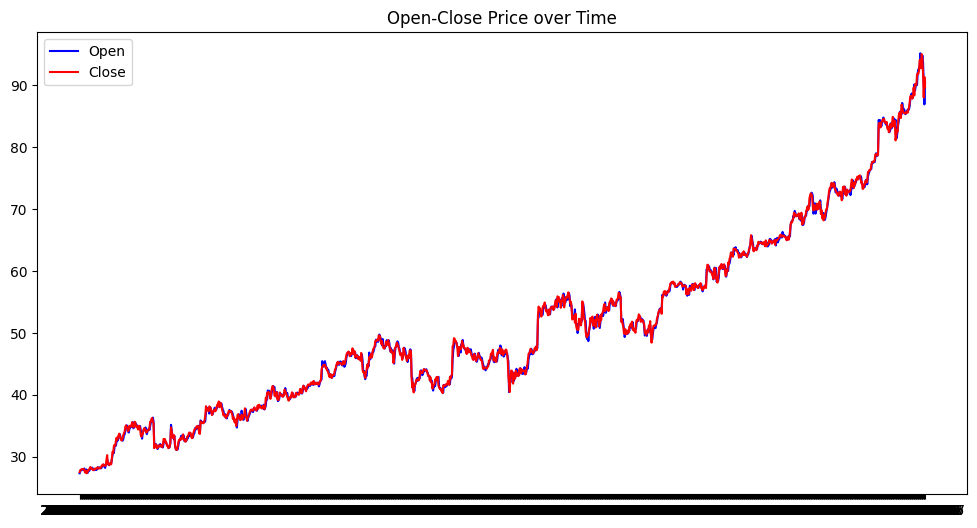

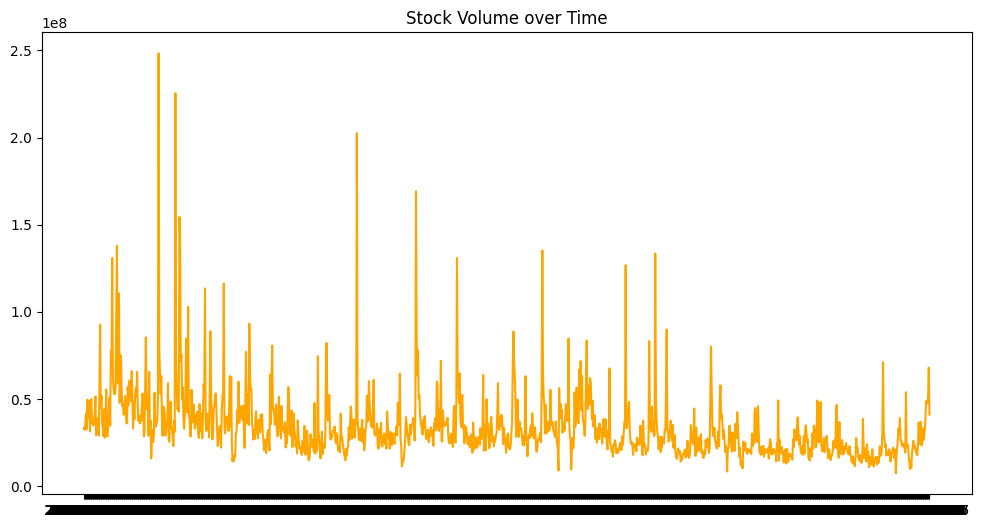

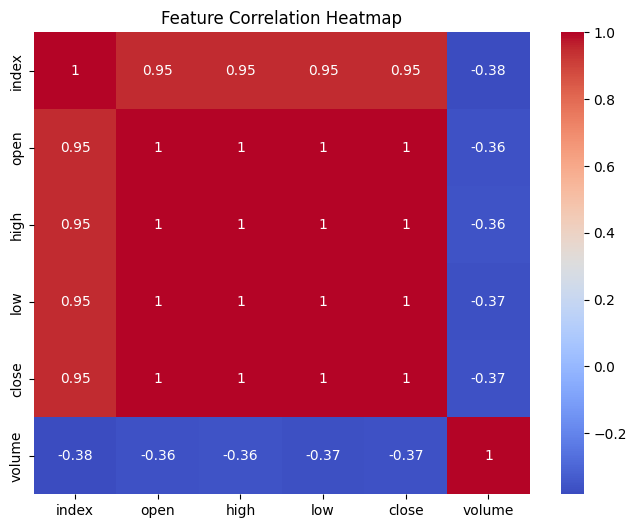

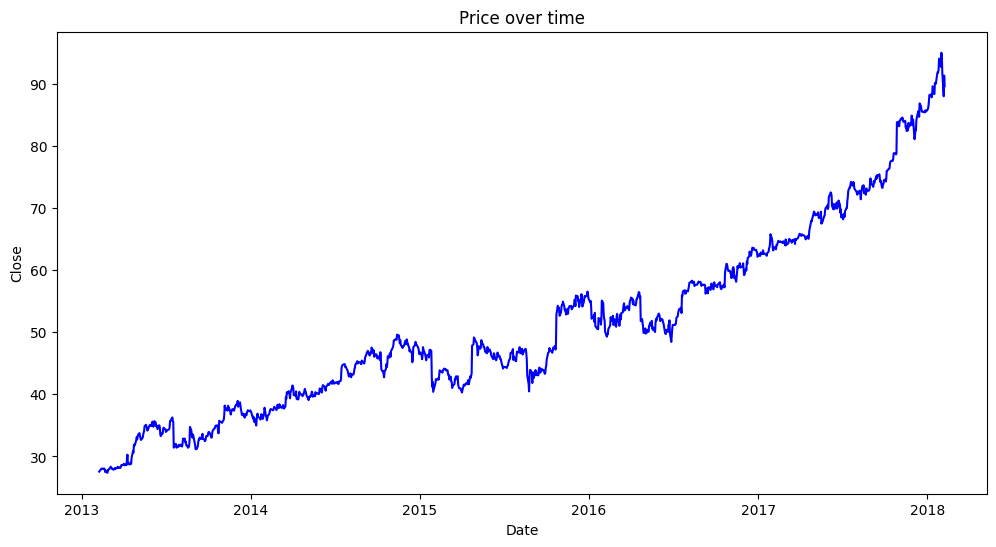

In [2]:
# Imports
from tensorflow import keras 
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from datetime import datetime

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'



data = pd.read_csv("MicrosoftStock.csv")
print(data.head())
print(data.info())
print(data.describe())


# Initial Data Visualization
# Plot 1 - Open and Close Prices of time
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['open'], label="Open",color="blue")
plt.plot(data['date'], data['close'], label="Close",color="red")
plt.title("Open-Close Price over Time")
plt.legend()
# plt.show()

# Plot 2 - Trading Volume (check for outliers)
plt.figure(figsize=(12,6))
plt.plot(data['date'],data['volume'],label="Volume",color="orange")
plt.title("Stock Volume over Time")
# plt.show()


# Drop non-numeric columns
numeric_data = data.select_dtypes(include=["int64","float64"])

# Plot 3 - Check for correlation between features
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
# plt.show()


# Convert the Data into Date time then create a date filter
data['date'] = pd.to_datetime(data['date'])

prediction = data.loc[
    (data['date'] > datetime(2013,1,1)) &
    (data['date'] < datetime(2018,1,1))
]

plt.figure(figsize=(12,6))
plt.plot(data['date'], data['close'],color="blue")
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Price over time")


# Prepare for the LSTM Model (Sequential)
stock_close = data.filter(["close"])
dataset = stock_close.values #convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

# Preprocessing Stages
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

training_data = scaled_data[:training_data_len] #95% of all out data

X_train, y_train = [], []


# Create a sliding window for our stock (60 days)
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])
    
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


# Build the Model
model = keras.models.Sequential()

# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))

# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))

# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))

# 4th Layer (Dropout)
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])


training = model.fit(X_train, y_train, epochs=20, batch_size=32)

In [27]:
from src.exp import *
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 1. Dataset with sliding windows
# ----------------------------
class BatteryDataset(Dataset):
    def __init__(self, cells, window_size=1000):
        """
        data: numpy array of shape (time_steps, num_features)
        window_size: length of each sequence
        """
        self.n_features = 0

        self.data_arrays = []
        for filename in cells: 
            for data in BatteryData.load(filename).timeseries_data:
                data = data.to_numpy()
                data = data[~np.isnan(data)]
                self.data_arrays.append(data)

        all_train_data = np.concatenate(self.data_arrays, axis=0)

        self.n_features = len(all_train_data)
        self.mean = all_train_data.mean(axis=0)
        self.std = all_train_data.std(axis=0)

        X = []
        for data in self.data_arrays:
            scaledx = (data - self.mean) / self.std 
            print(scaledx)
            for i in range(len(scaledx) - window_size):
                X.append(data[i:i+window_size])

        
        X = np.array(X, dtype=np.float32)
        self.X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

train_dataset = BatteryDataset(healthy_train_cells)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

train_dataset.X


[-1.19682401 -1.08394301 -1.19631776 ... -0.81532212  2.47154922
 -0.81548668]


array([[[0.000000e+00],
        [2.207430e+01],
        [9.900000e-02],
        ...,
        [2.197432e+01],
        [4.992400e+01],
        [2.198835e+01]],

       [[2.207430e+01],
        [9.900000e-02],
        [2.208599e+01],
        ...,
        [4.992400e+01],
        [2.198835e+01],
        [4.999000e+01]],

       [[9.900000e-02],
        [2.208599e+01],
        [1.990000e-01],
        ...,
        [2.198835e+01],
        [4.999000e+01],
        [2.197783e+01]],

       ...,

       [[1.021559e+02],
        [6.673740e+02],
        [1.020624e+02],
        ...,
        [7.171640e+02],
        [7.459326e+01],
        [7.172640e+02]],

       [[6.673740e+02],
        [1.020624e+02],
        [6.674740e+02],
        ...,
        [7.459326e+01],
        [7.172640e+02],
        [7.460411e+01]],

       [[1.020624e+02],
        [6.674740e+02],
        [1.020404e+02],
        ...,
        [7.172640e+02],
        [7.460411e+01],
        [7.173640e+02]]], dtype=float32)

In [121]:
from src.exp import *

# TODO: use config files and train_test_split.py code to get the list of healthy training cells
healthy_train_cells = [
    'data/preprocessed/UL-PUR_N10-EX9_18650_NCA_23C_0-100_0.5-0.5C_i_timeseries.pkl',
    # 'data/preprocessed/OX_1-1_pouch_LCO_40C_0-100_2-1.84C_a_timeseries.pkl',
]
X_train, mean, std = get_windows(cells=healthy_train_cells, window_size=100)

print(f'\nmean: \t{X_train.mean()}; \t{mean}\nstd: \t{X_train.std()}; \t{std}\nmin: \t{X_train.min()}\nmax: \t{X_train.max()}')
print(f'shape:\t {X_train.shape}')


[28.535 28.579 28.41  ... 24.449 24.405 24.172]
(43599,)

mean: 	28.008316040039062; 	28.006832060368353
std: 	2.958873987197876; 	2.9568782099014888
min: 	19.948999404907227
max: 	36.720001220703125
shape:	 (43499, 100, 1)


In [103]:
from tensorflow import keras 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers

training_data = X_train
timesteps = training_data.shape[1]
latent_dim = 10
num_features = 1

# encoder = Sequential([
#     LSTM(units=64, activation='tanh', input_shape=(timesteps, num_features)),
#     TimeDistributed(BatchNormalization()),
#     Dense(latent_dim)
# ])

# decoder = Sequential([
#     RepeatVector(timesteps, input_shape=(latent_dim,)),
#     LSTM(units=64, activation='tanh', return_sequences=True),
#     TimeDistributed(BatchNormalization()),
#     TimeDistributed(Dense(num_features))
# ])

encoder = Sequential()
encoder.add(LSTM(units=64, activation='tanh', input_shape=(timesteps, num_features)))
encoder.add(Dense(latent_dim))

decoder = Sequential()
decoder.add(RepeatVector(timesteps, input_shape=(latent_dim,)))
decoder.add(LSTM(units=64, activation='tanh', return_sequences=True))
decoder.add(TimeDistributed(Dense(num_features))) # Output layer

# Combine encoder and decoder
autoencoder = Sequential([encoder, decoder])

# Compile and train
opt = optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
autoencoder.compile(optimizer=opt, 
                    loss='mse', 
                    metrics=[keras.metrics.RootMeanSquaredError(), 'accuracy'])
callback = keras.callbacks.TerminateOnNaN()
history = autoencoder.fit(X_train, X_train, epochs=3, batch_size=32, callbacks=[callback])

print("Training Loss:", history.history['loss'])
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['root_mean_squared_error'])

Epoch 1/3


/Users/Hanita/Library/Python/3.12/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/Hanita/Library/Python/3.12/lib/python/site-packages/keras/src/layers/reshaping/repeat_vector.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1581/1581 ━━━━━━━━━━━━━━━━━━━━ 62s 38ms/step - accuracy: 0.0000e+00 - loss: 2171.6858 - root_mean_squared_error: 46.5115
Epoch 2/3
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.0000e+00 - loss: 1457.8237 - root_mean_squared_error: 38.1753
Epoch 3/3
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.0000e+00 - loss: 1224.5762 - root_mean_squared_error: 34.9901
Training Loss: [1888.6522216796875, 1401.98388671875, 1209.884033203125]
Training Accuracy: [0.0, 0.0, 0.0]
Validation Accuracy: [43.458621978759766, 37.443077087402344, 34.78338623046875]


In [122]:
training_data = X_train
timesteps = training_data.shape[1]
num_features = 1

autoencoder_model = build_lstm_autoencoder(input_shape=(timesteps, num_features))
autoencoder_model.compile(optimizer='adam', 
                          loss='mse',
                          metrics=[keras.metrics.RootMeanSquaredError(), 'accuracy'])
history = autoencoder_model.fit(X_train, X_train, epochs=3, batch_size=32)

print("Training Loss:", history.history['loss'])
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['root_mean_squared_error'])

Epoch 1/3
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 242s 166ms/step - accuracy: 0.0000e+00 - loss: 292.6661 - root_mean_squared_error: 16.1756
Epoch 2/3
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 230s 169ms/step - accuracy: 0.0000e+00 - loss: 6.0553 - root_mean_squared_error: 2.4572
Epoch 3/3
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 227s 167ms/step - accuracy: 0.0000e+00 - loss: 4.8605 - root_mean_squared_error: 2.2041
Training Loss: [102.1788558959961, 5.275640487670898, 4.627832412719727]
Training Accuracy: [0.0, 0.0, 0.0]
Validation Accuracy: [10.108355522155762, 2.2968761920928955, 2.1512396335601807]


In [123]:
test_cells_healthy = [
    'data/preprocessed/UL-PUR_R15-EX4_18650_NCA_23C_2.5-96.5_0.5-0.5C_d_timeseries.pkl'
]
X_test, _, _ = get_windows(cells=test_cells_healthy, window_size=100)

[27.623 27.441 27.41  ... 29.137 29.107 29.15 ]
(103615,)


In [124]:
predictions = autoencoder_model.predict(X_test)
predictions.shape, X_test.shape

3235/3235 ━━━━━━━━━━━━━━━━━━━━ 124s 38ms/step


((103515, 100, 1), (103515, 100, 1))

In [129]:
test_cells_unhealthy = [
    'data/preprocessed/LFP_15Ah_60SOC_cell1_MAX.pkl'
]
X_test_unhealthy, _, _ = get_windows(cells=test_cells_unhealthy, window_size=100)

unhealthy_predictions = autoencoder_model.predict(X_test_unhealthy)
unhealthy_predictions.shape, X_test_unhealthy.shape

[22.97453 22.97453 22.95643 ... 75.82197 77.06133 78.70295]
(2162,)
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


((2062, 100, 1), (2062, 100, 1))

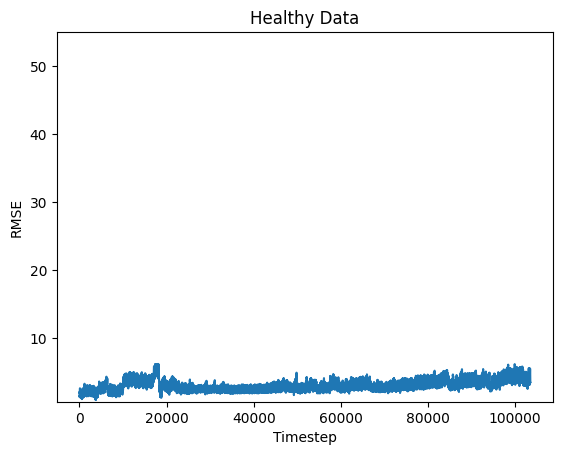

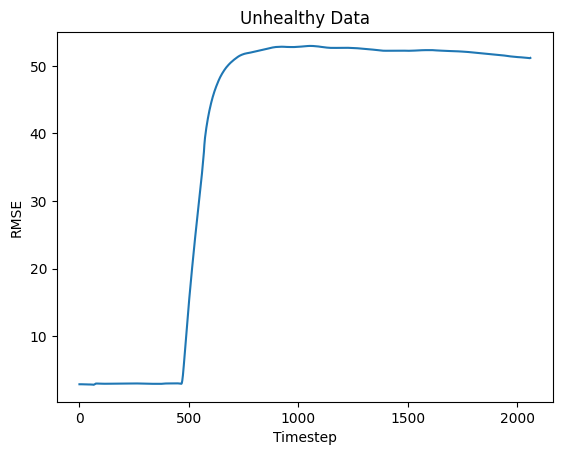

In [149]:
from src.exp import plot_results

plot_results(X_test, predictions, 'Healthy Data')
plot_results(X_test_unhealthy, unhealthy_predictions, 'Unhealthy Data')

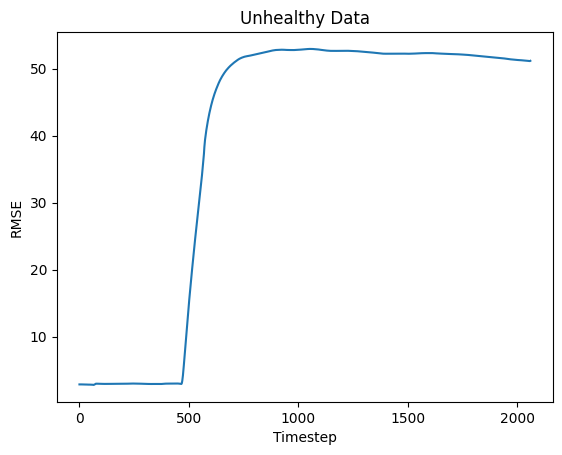

In [141]:
x_values = range(X_test_unhealthy.shape[0])
y_values = rmse_fn(x_values, data=X_test_unhealthy, preds=unhealthy_predictions)
plt.plot(x_values, y_values)
plt.title('Unhealthy Data')
plt.xlabel("Timestep")
plt.ylabel("RMSE")
plt.show()

In [108]:
from tensorflow import keras 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers

def build_lstm_autoencoder(input_shape):
    """
    Builds an LSTM autoencoder with TimeDistributed Batch Normalization.

    Args:
        input_shape (tuple): The shape of the input data (timesteps, features).

    Returns:
        tf.keras.models.Model: The LSTM autoencoder model.
    """
    inputs = Input(shape=input_shape)

    # Encoder
    encoded = LSTM(128, return_sequences=True)(inputs)
    encoded = TimeDistributed(BatchNormalization())(encoded)
    encoded = LSTM(64, activation='relu', return_sequences=False)(encoded)
    encoded = BatchNormalization()(encoded)

    # Decoder
    decoded = RepeatVector(input_shape[0])(encoded)
    decoded = LSTM(64, return_sequences=True)(decoded)
    decoded = TimeDistributed(BatchNormalization())(decoded)
    decoded = LSTM(128, return_sequences=True)(decoded)
    decoded = TimeDistributed(BatchNormalization())(decoded)
    decoded = TimeDistributed(Dense(input_shape[1]))(decoded) # Output layer matches input features

    # Autoencoder model
    autoencoder = Model(inputs, decoded)

    return autoencoder

training_data = X_train
timesteps = training_data.shape[1]
num_features = 1

autoencoder_model = build_lstm_autoencoder(input_shape=(timesteps, num_features))
autoencoder_model.compile(optimizer='adam', 
                          loss='mse',
                          metrics=[keras.metrics.RootMeanSquaredError(), 'accuracy'])
autoencoder_model.summary()

Model: "functional_120"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_64 (InputLayer)     │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_59 (LSTM)                  │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_40             │ (None, 100, 128)       │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_60 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_24 (RepeatVector) │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_61 (LSTM)                  │ (None, 100, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_41             │ (None, 100, 64)        │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_62 (LSTM)                  │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_42             │ (None, 100, 128)       │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_43             │ (None, 100, 1)         │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,473 (974.50 KB)

 Trainable params: 248,705 (971.50 KB)

 Non-trainable params: 768 (3.00 KB)

In [80]:
# ----------------------------
# 4. Inference & anomaly scoring
# ----------------------------
def compute_reconstruction_errors(model, dataloader, device="cpu"):
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            output = model(batch)
            loss = torch.mean((output - batch) ** 2, dim=(1,2))  # per sequence MSE
            errors.extend(loss.cpu().numpy())
    return np.array(errors)

# Compute reconstruction errors
train_errors = compute_reconstruction_errors(autoencoder, train_loader)

# Set threshold (e.g. 99th percentile of training errors)
threshold = np.percentile(train_errors, 99)

# Now evaluate on test data (healthy + runaway)
test_data = np.load("battery_test.npy")
test_dataset = BatteryDataset((test_data - mean) / std)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

test_errors = compute_reconstruction_errors(model, test_loader)

# Flag anomalies
anomalies = test_errors > threshold


AttributeError: 'Sequential' object has no attribute 'eval'